# Python Notebook: Problem Sheet 4 - Q7
Statistical Machine Learning Course \
Dept of Statistics, University of Oxford \
Authors: F. Imrie, F. Caron \
Last updated: 17/3/2025 \

# Image classification on the MNIST data set using convolutional neural networks

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.data import Dataset, experimental
from tensorflow.keras.backend import clear_session
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

clear_session() # Reset notebook state

AttributeError: 'RcParams' object has no attribute '_get'

We're using MNIST, a database of hand-written digits commonly used for training and testing image processing and machine learning techniques. The database is split into 60,000 training examples and 10,000 test examples. The digits are stored as 28-pixel 8-bit grayscale images. For each digit, a numerical label of 0-9 is provided.

In [ ]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()
x_train.shape, y_train.shape, x_test.shape, y_test.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

First, let's visualise some of the training data.

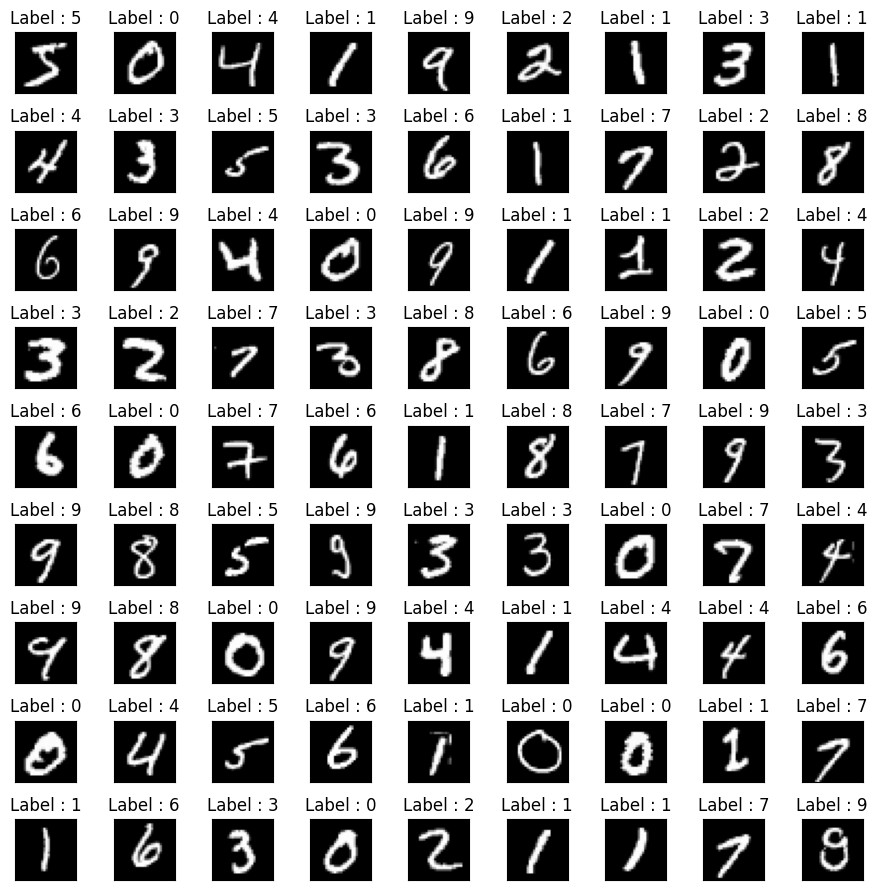

In [ ]:
fig, axes = plt.subplots(9,9,figsize=(9,9))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label : {y_train[i]}')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
fig.tight_layout()

In Keras, 2D convolutional layers take 3D tensors with dimensions (height, width, channels) as input. Since our images are grayscale, the input data has only a single channel,. We reshape the training data into 3D tensors, and convert the 8-bit integer values to floats.

In [ ]:
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))

x_train, x_test = x_train / 255.0, x_test / 255.0

# Building a CNN using the Keras API

The Sequential model allows us to build up our neural network's architecture by chaining together layers. This is a good place to get started with Keras, and covers the majority of real-world use cases.

In [ ]:
model = Sequential()

We first use a series of convolution and pooling layers to extract features from the images. Let's add one of each to the model.

In [ ]:
input = Input(shape=(28,28,1))
conv1 = Conv2D(filters=32, kernel_size=[5, 5], padding='same', activation='relu')
pool1 = MaxPooling2D(pool_size=[2, 2])

model.add(input)
model.add(conv1)
model.add(pool1)

We can inspect the architecture of our model.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 832 (3.25 KB)

 Trainable params: 832 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

The output of every conv2d and max_pooling2d layer is a 3D tensor of shape (height, width, channels). By applying pooling layers between convolutional layers, we can reduce the width and height as we go deeper in the network. Since smaller images are computationally cheaper to process, we can afford to use more output channels in subsequent convolutional layers. Let's add another convolution with more output channels, along with another pooling layer.

In [ ]:
conv2 = Conv2D(filters=64, kernel_size=[5, 5], padding='same', activation='relu')
pool2 = MaxPooling2D(pool_size=[2, 2])
model.add(conv2)
model.add(pool2)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,096 (203.50 KB)

 Trainable params: 52,096 (203.50 KB)

 Non-trainable params: 0 (0.00 B)

To use the output from the convolutional layers to perform the classification, we feed the output into one or more dense layers. We first flatten the output to create a 1D input layer, then add dense layers on top. MNIST has ten classes, the digits 0-9, so we use a final dense layer with ten outputs and a softmax activation to perform the classification.

In [ ]:
flat = Flatten()
dense1 = Dense(units=64, activation='relu')
dense2 = Dense(units=10, activation='softmax')
model.add(flat)
model.add(dense1)
model.add(dense2)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         200,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 253,514 (990.29 KB)

 Trainable params: 253,514 (990.29 KB)

 Non-trainable params: 0 (0.00 B)

Finally, we need to specify the training strategy.

In [ ]:
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

Here's a helper function to create a new instance of the model.

In [ ]:
def get_new_model():
    clear_session() # Free up memory
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(filters=32, kernel_size=[5, 5], padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=[2, 2]))
    model.add(Conv2D(filters=64, kernel_size=[5, 5], padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=[2, 2]))
    model.add(Flatten())
    model.add(Dense(units=64, activation='relu'))
    model.add(Dense(units=10, activation='softmax'))
    model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

Let's look at the final architecture of out model.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         200,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 253,514 (990.29 KB)

 Trainable params: 253,514 (990.29 KB)

 Non-trainable params: 0 (0.00 B)

# Training and evaluating the model

Finally, we can train our model. For each training epoch, TensorFlow reports training progress and accuracy during the training process.

In [ ]:
model.fit(x_train, y_train, batch_size=32, epochs=1)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9141 - loss: 0.2787


In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9819 - loss: 0.0521


[0.042997706681489944, 0.984499990940094]

We can continue training this model for additional epochs if needed.

In [ ]:
model.fit(x_train, y_train, epochs=2)

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9874 - loss: 0.0403
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9918 - loss: 0.0259


In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9883 - loss: 0.0356


[0.02921365387737751, 0.9901999831199646]